In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np

In [2]:
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Embedding
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv('train.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [22]:
df.tail()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0,0


In [13]:
df.iloc[0]

id                                                0000997932d777bf
comment_text     Explanation\nWhy the edits made under my usern...
toxic                                                            0
severe_toxic                                                     0
obscene                                                          0
threat                                                           0
insult                                                           0
identity_hate                                                    0
Name: 0, dtype: object

In [11]:
df[df['toxic']==1].head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
12,0005c987bdfc9d4b,Hey... what is it..\n@ | talk .\nWhat is it......,1,0,0,0,0,0
16,0007e25b2121310b,"Bye! \n\nDon't look, come or think of comming ...",1,0,0,0,0,0
42,001810bf8c45bf5f,You are gay or antisemmitian? \n\nArchangel WH...,1,0,1,0,1,1
43,00190820581d90ce,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!",1,0,1,0,1,0


In [4]:
X = df['comment_text']
y = df[df.columns[2:]].values

In [5]:
MAX_FEATURES = 200000

In [6]:
vectorizer = TextVectorization(max_tokens=MAX_FEATURES,
                               output_sequence_length=1800,
                               output_mode='int')

In [13]:
vectorizer.adapt(X.values)
vectorized_text = vectorizer(X.values)

In [7]:
vectorizer.adapt(X.values)

In [33]:
dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset = dataset.batch(16)
dataset = dataset.prefetch(8)

In [34]:
train = dataset.take(int(len(dataset)*.7))
val = dataset.skip(int(len(dataset)*.7)).take(int(len(dataset)*.2))
test = dataset.skip(int(len(dataset)*.9)).take(int(len(dataset)*.1))

In [20]:
model = Sequential()
model.add(Embedding(MAX_FEATURES+1, 32))
model.add(Bidirectional(LSTM(32, activation='tanh')))
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(6, activation='sigmoid'))


In [21]:
model.compile(loss='BinaryCrossentropy', optimizer='Adam')

In [22]:
history = model.fit(train, epochs=2, validation_data=val)

Epoch 1/2
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 8828s 1s/step - loss: 0.0640 - val_loss: 0.0467
Epoch 2/2
6981/6981 ━━━━━━━━━━━━━━━━━━━━ 7832s 1s/step - loss: 0.0463 - val_loss: 0.0411


In [ ]:
model.summary()

<Figure size 800x500 with 0 Axes>

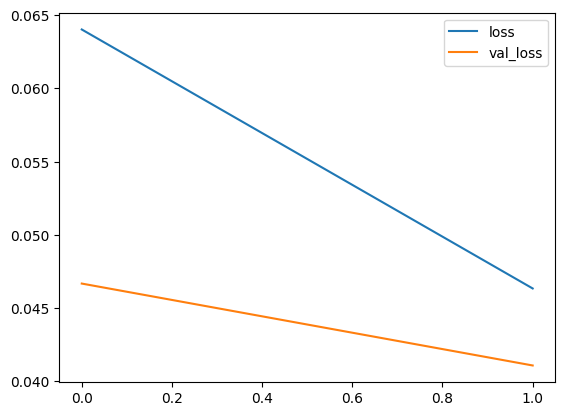

In [24]:
plt.figure(figsize=(8,5))
pd.DataFrame(history.history).plot()
plt.show()

In [25]:
input_text = vectorizer('You freaking suck! I am going to hit you.')
res = model.predict(np.expand_dims(input_text, 0))
print(res)
print("Predictions (>0.5):", (res > 0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.99598426 0.2980919  0.9319328  0.03384077 0.84203315 0.15789364]]
Predictions (>0.5): [[1 0 1 0 1 0]]


In [8]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [28]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [29]:
for batch in test.as_numpy_iterator(): 
    X_true, y_true = batch
    yhat = model.predict(X_true)
    
    y_true = y_true.flatten()
    yhat = yhat.flatten()
    
    pre.update_state(y_true, yhat)
    re.update_state(y_true, yhat)
    acc.update_state(y_true, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [30]:
print(f'Precision: {pre.result().numpy()}, Recall: {re.result().numpy()}, Accuracy: {acc.result().numpy()}')


Precision: 0.8080625534057617, Recall: 0.7407611608505249, Accuracy: 0.9835130572319031


In [32]:
import os
print(os.getcwd())

C:\Users\naroj


In [35]:
model.save('H:/Toxicity_Detection/toxicity_model.keras')

In [36]:
!pip install gradio

     ---------------------------------------- 24.2/24.2 MB 8.3 MB/s eta 0:00:00
     -------------------------------------- 369.0/369.0 kB 7.6 MB/s eta 0:00:00
     -------------------------------------- 105.1/105.1 kB 5.9 MB/s eta 0:00:00
     ---------------------------------------- 55.7/55.7 kB 2.8 MB/s eta 0:00:00
     -------------------------------------- 553.3/553.3 kB 7.0 MB/s eta 0:00:00
     -------------------------------------- 124.9/124.9 kB 3.7 MB/s eta 0:00:00
     -------------------------------------- 463.6/463.6 kB 4.8 MB/s eta 0:00:00
     -------------------------------------- 509.2/509.2 kB 6.4 MB/s eta 0:00:00
     ---------------------------------------- 74.3/74.3 kB 4.0 MB/s eta 0:00:00
     ---------------------------------------- 47.4/47.4 kB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 68.5/68.5 kB 3.6 MB/s eta 0:00:00
     -------------------------------------- 202.5/202.5 kB 6.2 MB/s eta 0:00:00
     -----------------------------------


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
model = load_model('H:/Toxicity_Detection/toxicity_model.keras')

In [10]:
import gradio as gr

In [9]:
from tensorflow.keras.models import load_model
model = load_model('H:/Toxicity_Detection/toxicity_model.keras')

In [11]:
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np

def score_comment(comment):
    vectorized_comment = vectorizer([comment])
    results = model.predict(vectorized_comment)
    
    toxicity_types = df.columns[2:]
    scores = results[0]
    
    text_output = "**Toxicity Detection Results:**\n\n"
    for idx, col in enumerate(toxicity_types):
        score = scores[idx]
        is_toxic = "✓ YES" if score > 0.5 else "✗ NO"
        text_output += f"**{col.replace('_', ' ').title()}:** {is_toxic} (Confidence: {score:.2%})\n"
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['red' if s > 0.5 else 'green' for s in scores]
    bars = ax.barh(toxicity_types, scores, color=colors, alpha=0.7)
    ax.set_xlabel('Confidence Score', fontsize=12)
    ax.set_title('Toxicity Detection Scores', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    
    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score + 0.02, i, f'{score:.2%}', va='center', fontweight='bold')
    
    plt.tight_layout()
    
    return text_output, fig

interface = gr.Interface(
    fn=score_comment,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter a comment to detect toxicity...",
        label="Comment Input"
    ),
    outputs=[
        gr.Textbox(label="Detection Results", lines=10),
        gr.Plot(label="Confidence Chart")
    ],
    title="🔍 Comment Toxicity Detector",
    description="Advanced AI model that detects toxic content. Get instant analysis with visual charts!",
    theme=gr.themes.Soft(),
    examples=[
        ["This is a great comment!"],
        ["You are so stupid"],
        ["I hate this"],
    ]
)

interface.launch(share=True)

C:\Users\naroj\AppData\Local\Programs\Python\Python311\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://83e6ad26c83a34dfe5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [35]:
history = model.fit(train, epochs=1, validation_data=val)

6981/6981 ━━━━━━━━━━━━━━━━━━━━ 10888s 2s/step - loss: 0.0416 - val_loss: 0.0383


In [38]:
model.save('H:/Toxicity_Detection/toxicity_model.keras')